# Docform ↔ Global Semantic Clustering using doc_id

This notebook implements the **doc-level** coherence test you asked for:

**Question:** Are **docform clusters** coherent with **global semantic clusters**?

We do this by joining **doc_id → docform_label** (from the docform manifest) with **doc_id → global_topic_cluster** (from the global semantic assignments file), and then computing:

- docform × global_topic contingency table
- purity (both directions)
- entropy (both directions)
- Cramér’s V (association effect size)
- mutual information + NMI
- heatmaps + stacked distributions + pie-ready exports

## Inputs you must provide (or the notebook will auto-discover)
- Docform manifest (doc_id → docform_label)
- Global semantic **per-document** assignments (doc_id → global_topic_cluster)

Your existing `semantic_all_topics.csv` is a **topic summary** and is **not usable** for doc-level joins.


In [3]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- PATHS ----------------
# Docform manifest (doc_id -> docform cluster label)
# in repo: outputs/docform/manifest/...
PATH_DOCFORM_MANIFEST = "outputs/docform/manifest_with_docform_clusters.csv.gz"  # doc_id -> docform cluster

# Global semantic per-document assignments (doc_id -> global_topic_cluster)
# YOU NEED THIS FILE. If None, we'll auto-search in common locations.
PATH_GLOBAL_DOC_ASSIGNMENTS = "outputs/semantic_global_tunedA/docs_with_topic_clusters.csv.gz"  # e.g., "outputs/semantic/global/doc_assignments.csv"

# Optional: global topic summary (for labeling only)
PATH_GLOBAL_TOPIC_SUMMARY = "outputs/semantic_global_tunedA/semantic_all_topics.csv"

# Auto-search locations for global per-doc assignments
AUTOSEARCH_DIRS = [
    "outputs/semantic",

]

# Exports
OUT_DIR = "outputs/analysis/docform_vs_global_semantic"
os.makedirs(OUT_DIR, exist_ok=True)

def exists(p): return p is not None and os.path.exists(p)

print("DOCFORM_MANIFEST:", PATH_DOCFORM_MANIFEST, "OK" if exists(PATH_DOCFORM_MANIFEST) else "MISSING")
print("GLOBAL_DOC_ASSIGNMENTS:", PATH_GLOBAL_DOC_ASSIGNMENTS, "OK" if exists(PATH_GLOBAL_DOC_ASSIGNMENTS) else "MISSING")
print("GLOBAL_TOPIC_SUMMARY:", PATH_GLOBAL_TOPIC_SUMMARY, "OK" if exists(PATH_GLOBAL_TOPIC_SUMMARY) else "MISSING")
print("OUT_DIR:", OUT_DIR)


DOCFORM_MANIFEST: outputs/docform/manifest_with_docform_clusters.csv.gz OK
GLOBAL_DOC_ASSIGNMENTS: outputs/semantic_global_tunedA/docs_with_topic_clusters.csv.gz OK
GLOBAL_TOPIC_SUMMARY: outputs/semantic_global_tunedA/semantic_all_topics.csv OK
OUT_DIR: outputs/analysis/docform_vs_global_semantic


## 1) Load docform manifest and pick columns


In [4]:
def load_csv_maybe_gz(path):
    if path.endswith(".gz"):
        return pd.read_csv(path, compression="gzip")
    return pd.read_csv(path)

def normalize_cols(cols):
    m = {}
    for c in cols:
        cn = str(c).strip().lower()
        cn = re.sub(r"\s+", "_", cn)
        m[cn] = c
    return m

def pick_col(df, candidates_norm, heuristics=None, required=True, label=""):
    cols_map = normalize_cols(df.columns)
    norm_cols = list(cols_map.keys())
    for cand in candidates_norm:
        if cand in cols_map:
            return cols_map[cand]
    if heuristics is not None:
        hits = [cols_map[n] for n in norm_cols if heuristics(n)]
        if len(hits) == 1:
            return hits[0]
        if len(hits) > 1:
            hits_sorted = sorted(hits, key=lambda x: (len(str(x)), str(x)))
            return hits_sorted[0]
    if required:
        raise KeyError(f"[{label}] Could not pick a column. Available: {list(df.columns)}")
    return None

docform_manifest = load_csv_maybe_gz(PATH_DOCFORM_MANIFEST)
print("docform_manifest shape:", docform_manifest.shape)
print("columns:", list(docform_manifest.columns)[:60])
display(docform_manifest.head(3))

man_doc_id = pick_col(
    docform_manifest,
    ["doc_id","document_id","docid","canonical_doc_id","path"],
    heuristics=lambda n: ("doc" in n and "id" in n) or (n=="path"),
    label="docform manifest doc_id"
)
docform_col = pick_col(
    docform_manifest,
    ["docform_cluster","form_kind","docform","doctype","doc_type","document_form","form"],
    heuristics=lambda n: ("docform" in n) or ("form_kind" in n) or ("doctype" in n) or ("doc_type" in n) or (n=="form"),
    label="docform label"
)

df_docform = docform_manifest[[man_doc_id, docform_col]].copy()
df_docform = df_docform.rename(columns={man_doc_id:"doc_id", docform_col:"docform_label"})
df_docform["doc_id"] = df_docform["doc_id"].astype(str)
df_docform["docform_label"] = df_docform["docform_label"].astype(str).str.strip()

print("Unique docforms:", df_docform["docform_label"].nunique())
display(df_docform["docform_label"].value_counts().head(20))


docform_manifest shape: (26177, 46)
columns: ['path', 'doc_id', 'sha256', 'source_root', 'rel_path', 'basename', 'ext', 'size_bytes', 'mtime_unix', 'extraction_method', 'ocr_error', 'encoding', 'bytes_read_for_preview', 'decode_replacements', 'pdf_page_count', 'img_width', 'img_height', 'img_format', 'img_mode', 'n_chars', 'n_lines', 'n_tokens', 'blank_lines', 'avg_line_len', 'max_line_len', 'digit_ratio', 'upper_ratio', 'non_ascii_ratio', 'email_count', 'phone_like_count', 'date_like_count', 'money_like_count', 'text_path', 'doc_family', 'has_text', 'text_missing', 'text_usable_now', 'has_emails', 'has_phones', 'has_dates', 'has_money', 'preview', 'docform_cluster', 'docform_cluster_prob', 'docform_label_raw', 'docform_coarse']


/var/folders/zx/5rm4vsbn4z90f_3mg3tbjqp5zmq2hl/T/ipykernel_68792/2413869151.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, compression="gzip")


,path,doc_id,sha256,source_root,rel_path,basename,ext,size_bytes,mtime_unix,extraction_method,...,text_usable_now,has_emails,has_phones,has_dates,has_money,preview,docform_cluster,docform_cluster_prob,docform_label_raw,docform_coarse
0,data/A. Evidence List_0_0_0_0.pdf,a2d4c4624e434b381d523764,a2d4c4624e434b381d523764d51ca8e91da114beea7d65...,A. Evidence List_0_0_0_0.pdf,A. Evidence List_0_0_0_0.pdf,A. Evidence List_0_0_0_0.pdf,.pdf,728648,1763410380,pdf_text_only,...,True,False,True,True,True,"50D-NY-3027571 \nType(s):1B, 1D, 1E\nItem #\nT...",c0001_r0000,1.000000,c0001_r0000,c0001
1,data/B. Flight Log_Released in U.S. v. Maxwell...,10fa669e5b637d8ec05b08ee,10fa669e5b637d8ec05b08eebcd6135c1bb0f0915d651e...,B. Flight Log_Released in U.S. v. Maxwell_0_0_...,B. Flight Log_Released in U.S. v. Maxwell_0_0_...,B. Flight Log_Released in U.S. v. Maxwell_0_0_...,.pdf,11669768,1763410380,pdf_text_only,...,True,False,True,False,False,*\nP\nu\nb\nl\ni\nc\nl\ny \nr\ne\nl\ne\na\ns\n...,c0004_r0004,0.902173,c0004_r0004,c0004
2,data/B. Flight Log_Released in U.S. v. Maxwell...,f2f8c7628ddc9cbc1cf6a753,f2f8c7628ddc9cbc1cf6a7532b847ae45eec1165cb400f...,B. Flight Log_Released in U.S. v. Maxwell_Part...,B. Flight Log_Released in U.S. v. Maxwell_Part...,B. Flight Log_Released in U.S. v. Maxwell_Part...,.pdf,7429146,1763410380,pdf_text_only,...,True,False,False,False,False,",\n*Publicly \nreleased in \nU.S. v. Maxwell \...",c0004_r0001,1.000000,c0004_r0001,c0004


Unique docforms: 23


docform_label
nan            23140
c0004_r0000      587
c0004_r0003      427
c0006_r0001      310
c0004_r0004      235
c0004_r0002      232
c0001_r0000      166
c0003_r0000      115
c0004_r0001      113
c0007_r0002      111
c0000_r0000       86
c0007_r0001       86
c0003_r0005       85
c0003_r0006       72
c0005_r0000       71
c0002_r0000       67
c0003_r0003       59
c0003_r0002       57
c0003_r0001       40
noise             39
Name: count, dtype: int64

## 2) Load global per-document topic assignments (doc_id → global_topic_cluster)

If you don’t set `PATH_GLOBAL_DOC_ASSIGNMENTS`, we auto-search for a CSV that contains both a doc-id-like column and a topic/cluster-like column.


In [5]:
def discover_assignment_csv(dirs):
    candidates = []
    patterns = [
        "*global*assign*.csv",
        "*global*doc*.csv",
        "*doc*topic*.csv",
        "*doc*topics*.csv",
        "*doc*cluster*.csv",
        "*assign*.csv",
        "*labels*.csv",
        "*manifest*topic*.csv",
    ]
    for d in dirs:
        if d and os.path.isdir(d):
            for pat in patterns:
                candidates.extend(glob.glob(os.path.join(d, "**", pat), recursive=True))
    # keep unique, stable ordering
    candidates = sorted(list(dict.fromkeys(candidates)))
    return candidates

def looks_like_doc_assignment(df):
    cols = normalize_cols(df.columns)
    has_doc = any(k in cols for k in ["doc_id","document_id","docid","canonical_doc_id","path"])
    has_topic = any(k in cols for k in ["topic","topic_id","topic_label","cluster","cluster_id","topic_cluster","label","group_index"])
    return has_doc and has_topic

def load_global_assignments(path):
    df = pd.read_csv(path)
    cols = normalize_cols(df.columns)
    doc_col = pick_col(df, ["doc_id","document_id","docid","canonical_doc_id","path"],
                       heuristics=lambda n: ("doc" in n and "id" in n) or (n=="path"),
                       label="global assignment doc_id")
    topic_col = pick_col(df, ["topic_cluster","topic_id","topic","cluster_id","cluster","label","topic_label","group_index"],
                         heuristics=lambda n: any(k in n for k in ["topic","cluster","label","group"]),
                         label="global assignment topic")
    out = df[[doc_col, topic_col]].copy()
    out = out.rename(columns={doc_col:"doc_id", topic_col:"global_topic_cluster"})
    out["doc_id"] = out["doc_id"].astype(str)
    out["global_topic_cluster"] = out["global_topic_cluster"].astype(str).str.strip()
    return out

global_assign = None
assign_path_used = None

if exists(PATH_GLOBAL_DOC_ASSIGNMENTS):
    global_assign = load_global_assignments(PATH_GLOBAL_DOC_ASSIGNMENTS)
    assign_path_used = PATH_GLOBAL_DOC_ASSIGNMENTS
else:
    candidates = discover_assignment_csv(AUTOSEARCH_DIRS)
    # try best candidate first by name hints
    for p in candidates:
        try:
            tmp = pd.read_csv(p, nrows=5)
        except Exception:
            continue
        if looks_like_doc_assignment(tmp):
            # full load
            try:
                global_assign = load_global_assignments(p)
                assign_path_used = p
                break
            except Exception:
                continue

if global_assign is None:
    print("Auto-search dirs:", AUTOSEARCH_DIRS)
    print("Candidates (first 30):", discover_assignment_csv(AUTOSEARCH_DIRS)[:30])
    raise RuntimeError(
        "Missing global per-document assignments.\n"
        "You must provide a CSV with columns like: doc_id + topic_cluster (or similar).\n"
        "Set PATH_GLOBAL_DOC_ASSIGNMENTS to that file."
    )

print("Using global assignments:", assign_path_used)
print("global_assign shape:", global_assign.shape)
display(global_assign.head(5))


Using global assignments: outputs/semantic_global_tunedA/docs_with_topic_clusters.csv.gz
global_assign shape: (2145, 2)


,doc_id,global_topic_cluster
0,06acba39d689a223aa0163cb,11
1,096ab47734e69af0a5087760,7
2,0cb38f909410f23329a9f0cd,-1
3,1479b85b219e177a25c353b1,7
4,251c498d7e40ccf125150855,7


## 3) Join: docform_label vs global_topic_cluster


In [6]:
merged = df_docform.merge(global_assign, on="doc_id", how="inner")
print("Merged shape:", merged.shape)
print("Docs lost (docform only):", len(df_docform) - merged.shape[0])
print("Unique docforms:", merged["docform_label"].nunique(), "| Unique global topics:", merged["global_topic_cluster"].nunique())
merged.head()


Merged shape: (2235, 3)
Docs lost (docform only): 23942
Unique docforms: 22 | Unique global topics: 58


,doc_id,docform_label,global_topic_cluster
0,a2d4c4624e434b381d523764,c0001_r0000,9
1,10fa669e5b637d8ec05b08ee,c0004_r0004,28
2,f2f8c7628ddc9cbc1cf6a753,c0004_r0001,10
3,77acffcbcfeb31400c0f8a58,c0004_r0001,10
4,6d7c2a8cc3fb644f7c354993,c0004_r0001,10


## 4) Contingency table + alignment metrics


In [7]:
ct = pd.crosstab(merged["docform_label"], merged["global_topic_cluster"])
display(ct.head(10))

def entropy(p, eps=1e-12):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log2(p + eps)).sum())

def purity_from_ct(ct, axis=1):
    arr = ct.to_numpy()
    total = arr.sum()
    if total == 0:
        return np.nan
    return (arr.max(axis=1).sum() / total) if axis == 1 else (arr.max(axis=0).sum() / total)

def mean_entropy_rows(ct):
    arr = ct.to_numpy(dtype=float)
    row_sums = arr.sum(axis=1, keepdims=True)
    probs = np.divide(arr, row_sums, out=np.zeros_like(arr), where=row_sums!=0)
    ent = np.array([entropy(r) for r in probs])
    weights = row_sums.squeeze()
    weights = weights / weights.sum() if weights.sum() else weights
    return float((ent * weights).sum()) if weights.sum() else np.nan

def mean_entropy_cols(ct):
    arr = ct.to_numpy(dtype=float)
    col_sums = arr.sum(axis=0, keepdims=True)
    probs = np.divide(arr, col_sums, out=np.zeros_like(arr), where=col_sums!=0)
    ent = np.array([entropy(c) for c in probs.T])
    weights = col_sums.squeeze()
    weights = weights / weights.sum() if weights.sum() else weights
    return float((ent * weights).sum()) if weights.sum() else np.nan

def cramers_v(ct):
    obs = ct.to_numpy(dtype=float)
    n = obs.sum()
    if n == 0:
        return np.nan
    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - expected) ** 2 / expected)
    r, k = obs.shape
    denom = min(r-1, k-1)
    return float(np.sqrt((chi2 / n) / (denom if denom > 0 else 1)))

def mutual_information(ct):
    obs = ct.to_numpy(dtype=float)
    n = obs.sum()
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan
    pxy = obs / n
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        mi = np.nansum(pxy * np.log2(np.divide(pxy, px @ py, out=np.zeros_like(pxy), where=(px @ py) > 0) + 1e-12))
    hx = entropy(px.squeeze())
    hy = entropy(py.squeeze())
    nmi = mi / ((hx + hy)/2 if (hx + hy) > 0 else 1.0)
    return float(mi), float(nmi), float(hx), float(hy)

results = {
    "purity_docform_to_global": purity_from_ct(ct, axis=1),
    "purity_global_to_docform": purity_from_ct(ct, axis=0),
    "mean_entropy_docform_rows": mean_entropy_rows(ct),
    "mean_entropy_global_cols": mean_entropy_cols(ct),
    "cramers_v": cramers_v(ct),
}
mi, nmi, hx, hy = mutual_information(ct)
results.update({"mutual_information": mi, "nmi": nmi, "entropy_docform": hx, "entropy_global": hy})

display(pd.Series(results).sort_values(ascending=False))

pd.Series(results).to_frame("value").to_csv(os.path.join(OUT_DIR, "docform_vs_global_alignment_metrics.csv"))
ct.to_csv(os.path.join(OUT_DIR, "contingency_docform_x_global_topic.csv"))
print("Saved metrics + contingency to", OUT_DIR)


global_topic_cluster,-1,0,1,10,11,12,13,14,15,16,...,51,52,53,54,55,56,6,7,8,9
docform_label,,,,,,,,,,,,,,,,,,,,,
c0000_r0000,9,0,0,0,1,0,0,1,0,0,...,1,0,2,3,0,0,1,8,0,0
c0001_r0000,43,0,0,0,1,1,2,1,2,2,...,0,0,0,0,1,3,0,3,1,1
c0002_r0000,21,0,0,4,1,0,0,0,0,1,...,0,9,2,2,0,1,3,0,0,0
c0003_r0000,15,1,0,1,0,2,1,0,5,1,...,1,0,1,0,0,3,0,20,3,3
c0003_r0001,7,0,0,1,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
c0003_r0002,0,0,0,0,0,0,0,1,0,0,...,0,0,1,1,0,1,1,1,0,1
c0003_r0003,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,3
c0003_r0004,1,0,2,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,4,3,2
c0003_r0005,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,1


entropy_global               5.170333
mean_entropy_docform_rows    4.368441
entropy_docform              3.799564
mean_entropy_global_cols     2.997673
mutual_information           0.801892
purity_global_to_docform     0.307830
cramers_v                    0.288434
purity_docform_to_global     0.228635
nmi                          0.178796
dtype: float64

Saved metrics + contingency to outputs/analysis/docform_vs_global_semantic


## 5) Visuals: stacked bars + heatmap


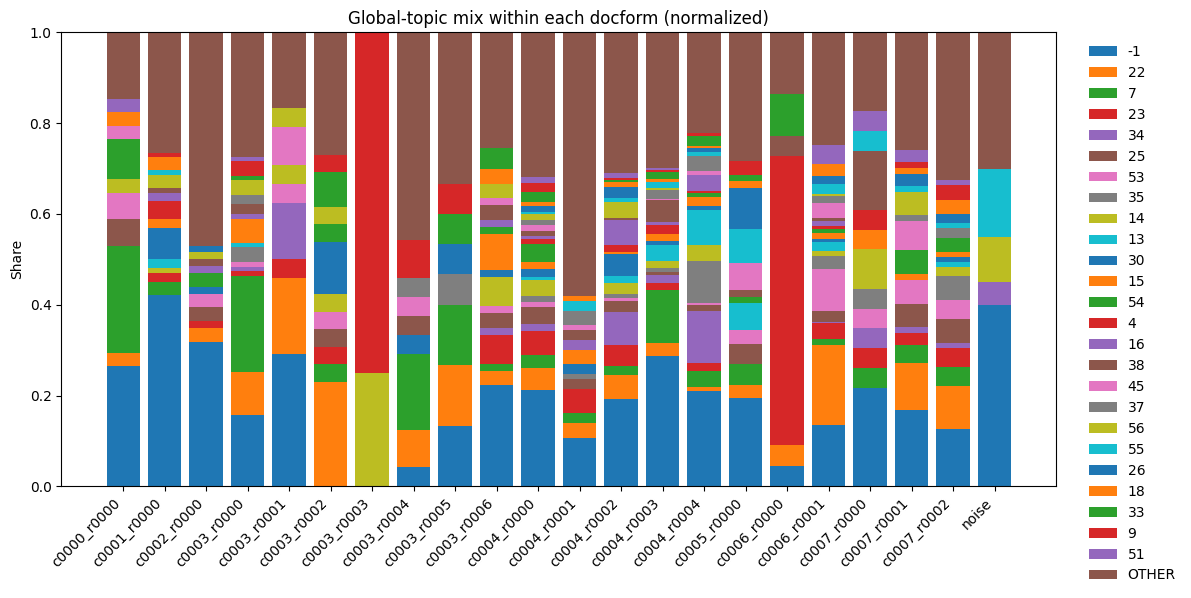

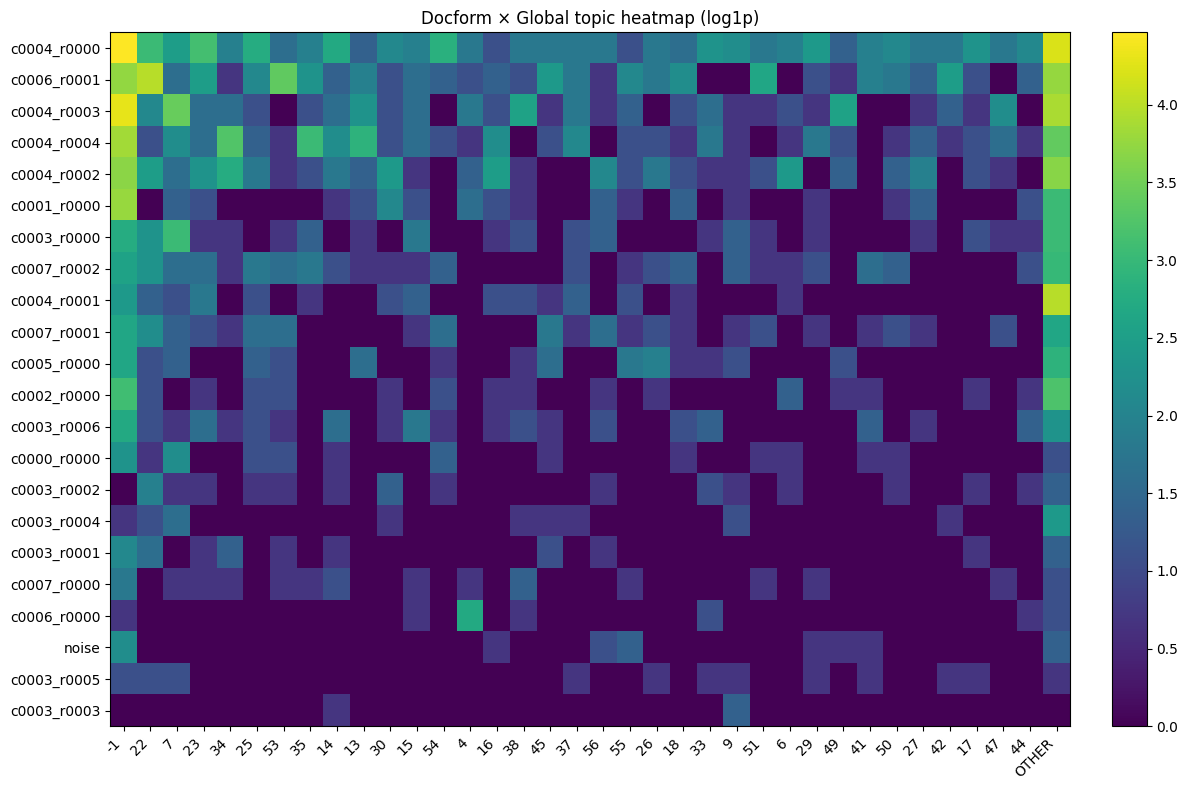

In [8]:
def topk_columns(ct, k=25):
    col_sums = ct.sum(axis=0).sort_values(ascending=False)
    top = list(col_sums.head(k).index)
    ct2 = ct[top].copy()
    rest = ct.drop(columns=top).sum(axis=1)
    if rest.sum() > 0:
        ct2["OTHER"] = rest
    return ct2

def topk_rows(ct, k=30):
    row_sums = ct.sum(axis=1).sort_values(ascending=False)
    top = list(row_sums.head(k).index)
    ct2 = ct.loc[top].copy()
    rest = ct.drop(index=top).sum(axis=0)
    if rest.sum() > 0:
        ct2.loc["OTHER_DOCFORMS"] = rest
    return ct2

def stacked_bar_docform(ct, topk_topics=25, normalize=True, figsize=(12, 6)):
    ct2 = topk_columns(ct, k=topk_topics)
    data = ct2.div(ct2.sum(axis=1), axis=0) if normalize else ct2
    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(data))
    x = np.arange(len(data.index))
    for col in data.columns:
        ax.bar(x, data[col].values, bottom=bottom, label=str(col))
        bottom += data[col].values
    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45, ha="right")
    ax.set_ylabel("Share" if normalize else "Count")
    ax.set_title("Global-topic mix within each docform" + (" (normalized)" if normalize else ""))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

def heatmap_ct(ct, topk_docforms=30, topk_topics=35, log1p=True, figsize=(12, 8)):
    ct_small = topk_rows(ct, k=topk_docforms)
    ct_small = topk_columns(ct_small, k=topk_topics)
    mat = ct_small.to_numpy(dtype=float)
    if log1p:
        mat = np.log1p(mat)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat, aspect="auto")
    ax.set_yticks(np.arange(ct_small.shape[0]))
    ax.set_yticklabels(ct_small.index)
    ax.set_xticks(np.arange(ct_small.shape[1]))
    ax.set_xticklabels(ct_small.columns, rotation=45, ha="right")
    ax.set_title("Docform × Global topic heatmap" + (" (log1p)" if log1p else ""))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

stacked_bar_docform(ct, topk_topics=25, normalize=True)
heatmap_ct(ct, topk_docforms=30, topk_topics=35, log1p=True)


## 6) Pie-chart-ready exports

These are direct pie inputs:
- For each docform: its distribution over global topics (top-K + OTHER)
- For each global topic: its distribution over docforms (top-K + OTHER)


In [9]:
def pie_ready_docforms(ct, topk=8):
    out = []
    for docform, row in ct.iterrows():
        s = row.sort_values(ascending=False)
        top = s.head(topk)
        other = s.iloc[topk:].sum()
        for topic, val in top.items():
            out.append({"docform_label": docform, "slice": str(topic), "count": int(val)})
        if other > 0:
            out.append({"docform_label": docform, "slice": "OTHER", "count": int(other)})
    return pd.DataFrame(out)

def pie_ready_topics(ct, topk=8):
    out = []
    for topic in ct.columns:
        s = ct[topic].sort_values(ascending=False)
        top = s.head(topk)
        other = s.iloc[topk:].sum()
        for docform, val in top.items():
            out.append({"global_topic_cluster": str(topic), "slice": str(docform), "count": int(val)})
        if other > 0:
            out.append({"global_topic_cluster": str(topic), "slice": "OTHER", "count": int(other)})
    return pd.DataFrame(out)

pies_docform = pie_ready_docforms(ct, topk=8)
pies_topic = pie_ready_topics(ct, topk=8)

pies_docform.to_csv(os.path.join(OUT_DIR, "pie_docform_globaltopic_mix.csv"), index=False)
pies_topic.to_csv(os.path.join(OUT_DIR, "pie_globaltopic_docform_mix.csv"), index=False)

print("Saved pies to", OUT_DIR)
display(pies_docform.head(12))


Saved pies to outputs/analysis/docform_vs_global_semantic


,docform_label,slice,count
0,c0000_r0000,-1,9
1,c0000_r0000,7,8
2,c0000_r0000,54,3
3,c0000_r0000,25,2
4,c0000_r0000,53,2
5,c0000_r0000,18,1
6,c0000_r0000,41,1
7,c0000_r0000,45,1
8,c0000_r0000,OTHER,7
9,c0001_r0000,-1,43


## 7) Optional: compare to within-docform topic clustering via doc_id (if you export per-doc local assignments)

If you also export per-doc assignments from each per-docform semantic run:
`outputs/semantic/{docform}/doc_topic_assignments.csv` (doc_id → local_topic_id)

…then we can compute within each docform:
- local_topic × global_topic contingency
- how fragmented each local topic is across global topics (and vice versa)

This section is stubbed and will auto-discover those files if you have them.


In [10]:
# ---- OPTIONAL: local per-doc assignments per docform ----
# If you don't have these files, skip this section.

LOCAL_ASSIGN_FILENAME_CANDIDATES = [
    "doc_topic_assignments.csv",
    "doc_topics.csv",
    "doc_topic_labels.csv",
    "assignments.csv",
]

def try_load_local_assignments(base_dir, docform_label):
    for fn in LOCAL_ASSIGN_FILENAME_CANDIDATES:
        p = os.path.join(base_dir, docform_label, fn)
        if os.path.exists(p):
            df = pd.read_csv(p)
            cols = normalize_cols(df.columns)
            doc_col = pick_col(df, ["doc_id","document_id","docid","canonical_doc_id","path"],
                               heuristics=lambda n: ("doc" in n and "id" in n) or (n=="path"),
                               label=f"local assign doc_id ({docform_label})")
            topic_col = pick_col(df, ["topic_cluster","topic_id","topic","cluster_id","cluster","label","topic_label","group_index"],
                                 heuristics=lambda n: any(k in n for k in ["topic","cluster","label","group"]),
                                 label=f"local assign topic ({docform_label})")
            out = df[[doc_col, topic_col]].copy()
            out = out.rename(columns={doc_col:"doc_id", topic_col:"local_topic_id"})
            out["doc_id"] = out["doc_id"].astype(str)
            out["local_topic_id"] = out["local_topic_id"].astype(str).str.strip()
            out["docform_label"] = docform_label
            return out, p
    return None, None

local_all = []
used_paths = []
for lab in sorted(df_docform["docform_label"].unique()):
    df_local, p = try_load_local_assignments("outputs/semantic", lab)
    if df_local is not None:
        local_all.append(df_local)
        used_paths.append(p)

if not local_all:
    print("No per-doc local topic assignment files found. (This is OK.)")
else:
    local_assign = pd.concat(local_all, ignore_index=True)
    print("Loaded local per-doc assignments:", local_assign.shape)
    print("Example files used (first 10):", used_paths[:10])

    # join to global topic by doc_id
    j = local_assign.merge(global_assign, on="doc_id", how="inner")
    print("Joined local↔global via doc_id:", j.shape)

    # per docform: local_topic × global_topic contingency (top docforms only for display)
    top_docforms = df_docform["docform_label"].value_counts().head(10).index.tolist()
    for lab in top_docforms:
        jj = j[j["docform_label"] == lab]
        if jj.empty:
            continue
        ct_lg = pd.crosstab(jj["local_topic_id"], jj["global_topic_cluster"])
        print("\nDocform:", lab, "| local topics:", ct_lg.shape[0], "| global topics:", ct_lg.shape[1])
        display(ct_lg.head(10))


No per-doc local topic assignment files found. (This is OK.)
